# Notebook to finetune the best_model.pt on a train.csv instruction set.
Notebook assumes kaggle environment, change paths and vars as necessary

In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
os.environ["WANDB_DIR"] = "/kaggle/tmp"
os.environ["WANDB_CACHE_DIR"] = "/kaggle/tmp"
os.environ["WANDB_CONFIG_DIR"] = "/kaggle/tmp"

In [ ]:
import os, sys

# Detect runtime environment
IS_KAGGLE = os.path.exists('/kaggle/working')
IS_COLAB  = 'google.colab' in str(get_ipython()) if hasattr(__builtins__, '__import__') else False
try:
    import google.colab
    IS_COLAB = True
except ImportError:
    pass

WORK_DIR = '/kaggle/working' if IS_KAGGLE else '/content'
print(f"Runtime: {'Kaggle' if IS_KAGGLE else 'Colab' if IS_COLAB else 'Other'}")
print(f"Working dir: {WORK_DIR}")

os.system("pip install -q selfies wandb pyarrow")
os.system("pip install -q 'rdkit>=2023.3'")
os.system("pip install -q 'transformers>=4.40' 'sentence-transformers>=2.6'")

print("Dependencies ready.")

Runtime: Kaggle
Working dir: /kaggle/working
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.7/36.7 MB 49.2 MB/s eta 0:00:00
Dependencies ready.


In [ ]:
import subprocess, shutil

GIT_URL    = "https://github.com/vivaikmalik/morpheus.git"
GIT_BRANCH = "text-condition"
REPO_NAME  = "morpheus"
REPO_PATH  = os.path.join(WORK_DIR, REPO_NAME)

# if not os.path.exists(REPO_PATH):
#     subprocess.run(["git", "clone", "--branch", GIT_BRANCH, "--single-branch", GIT_URL, REPO_PATH], check=True)
#     print(f"Cloned branch '{GIT_BRANCH}' into {REPO_PATH}")
# else:
#     subprocess.run(["git", "-C", REPO_PATH, "fetch", "origin"], check=True)
#     subprocess.run(["git", "-C", REPO_PATH, "checkout", GIT_BRANCH], check=True)
#     subprocess.run(["git", "-C", REPO_PATH, "pull", "origin", GIT_BRANCH], check=True)
#     print(f"Repo already present — checked out and pulled '{GIT_BRANCH}'.")





In [4]:
# print("Repo ready.")
! git clone -b prompt-condition https://github.com/vivaikmalik/morpheus.git
if REPO_PATH not in sys.path:
    sys.path.insert(0, REPO_PATH)

Cloning into 'morpheus'...
remote: Enumerating objects: 422, done.
remote: Counting objects: 100% (193/193), done.
remote: Compressing objects: 100% (147/147), done.
remote: Total 422 (delta 86), reused 143 (delta 45), pack-reused 229 (from 2)
Receiving objects: 100% (422/422), 1.45 GiB | 34.04 MiB/s, done.
Resolving deltas: 100% (119/119), done.
Updating files: 100% (126/126), done.


In [5]:
import wandb
os.environ.pop("WANDB_MODE", None)
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
secret_value_0 = user_secrets.get_secret("WANDB_API_KEY")
wandb.login(key=secret_value_0)

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: kains-praveen-kavuluri (marl-project) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [7]:
import zipfile
import os
dataset_url = "https://huggingface.co/datasets/zjunlp/Mol-Instructions/resolve/main/data/Molecule-oriented_Instructions.zip"
zip_file = "Molecule-oriented_Instructions.zip"
extract_dir = "./data_mol_instruct"

# Download and unzip
if not os.path.exists(extract_dir):
    print(f"Downloading {dataset_url}...")
    os.system(f"wget -q {dataset_url} -O {zip_file}")

    print(f"Extracting {zip_file}...")
    with zipfile.ZipFile(zip_file, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)
    print("Extraction complete.")
else:
    print("Dataset already downloaded and extracted.")



Dataset already downloaded and extracted.


In [8]:
import pandas as pd
import json
import os
import wandb  

# Load JSON
json_path = os.path.join("./", "data_mol_instruct/Molecule-oriented_Instructions/description_guided_molecule_design.json")
with open(json_path, 'r') as f:
    data = json.load(f)

# Convert to DataFrame
df = pd.DataFrame(data)

def format_prompt(row):
    instruction = row.get('instruction', '')
    inp = row.get('input', '')
    if inp:
        return f"{instruction}\nInput: {inp}"
    return instruction

df['prompt'] = df.apply(format_prompt, axis=1)
df['response'] = df['output']

# Split into train and validation
df['split'] = df['metadata'].apply(lambda m: m['split'])
train_df_ = df[df['split'] == 'train'][['prompt', 'response']]
train_df = train_df_.sample(frac=0.9, random_state=42)
val_df = train_df_.drop(train_df.index)
test_df = df[df['split'] == 'test'][['prompt', 'response']]

# Save to CSV
train_csv_path = os.path.join("./", "train.csv")
val_csv_path = os.path.join("./", "val.csv")
test_csv_path = os.path.join("./", "test.csv")

train_df.to_csv(train_csv_path, index=False)
val_df.to_csv(val_csv_path, index=False)
test_df.to_csv(test_csv_path, index=False)

# Log dataset
# artifact = wandb.Artifact("morpheus-datasets", type="dataset")
# artifact.add_file(train_csv_path)
# artifact.add_file(val_csv_path)
# artifact.add_file(test_csv_path)
# wandb.log_artifact(artifact)

print(f"Saved train csv to {train_csv_path}")
print(f"Saved val csv to {val_csv_path}")

print(df['split'].value_counts())
print(len(train_df), len(val_df), len(test_df))

Saved train csv to ./train.csv
Saved val csv to ./val.csv
split
train    297319
test       1000
Name: count, dtype: int64
267587 29732 1000


In [ ]:

# Default: train.csv is assumed to already be in the notebook working directory
DATASET_CSV = os.path.join(WORK_DIR, "train.csv")

import pandas as pd
assert os.path.exists(DATASET_CSV), f"train.csv not found at {DATASET_CSV}"
df_check = pd.read_csv(DATASET_CSV, nrows=3)
assert "prompt"   in df_check.columns, "Missing 'prompt' column"
assert "response" in df_check.columns, "Missing 'response' column"
print(f"Dataset OK — {len(pd.read_csv(DATASET_CSV)):,} rows")
print(df_check[["prompt", "response"]].to_string())

Dataset OK — 267,587 rows
                                                                                                                                                                         prompt                                                                                                                                                                                                                                                                                                                                                                                                                                                                  response
0                                                            Design a molecule that meets the criteria outlined in the description.\nInput: The molecule is an aromatic ketone.                                                                                                                                                                     

In [ ]:
from pathlib import Path
# Copy dataset into repo root
TRAIN_CSV_DEST = os.path.join(REPO_PATH, "train.csv")
shutil.copy(DATASET_CSV, TRAIN_CSV_DEST)
print(f"Dataset copied → {TRAIN_CSV_DEST}")

# Pre-trained diffusion model weights
PRETRAINED_WEIGHTS = Path(os.path.join(REPO_PATH, "checkpoints")) / Path("best_model.pt")   # <-- set your path here

checkpoint_dir = os.path.join(REPO_PATH, "checkpoints")
os.makedirs(checkpoint_dir, exist_ok=True)

if PRETRAINED_WEIGHTS and os.path.exists(PRETRAINED_WEIGHTS):
    shutil.copy(PRETRAINED_WEIGHTS, os.path.join(checkpoint_dir, "best_model.pt"))
    print(f"Pre-trained weights copied → {checkpoint_dir}/best_model.pt")
elif PRETRAINED_WEIGHTS:
    print(f"WARNING: weights not found at {PRETRAINED_WEIGHTS}. Training from scratch.")
else:
    print("No pre-trained weights specified. Training from scratch.")

Dataset copied → /kaggle/working/morpheus/train.csv


SameFileError: PosixPath('/kaggle/working/morpheus/checkpoints/best_model.pt') and '/kaggle/working/morpheus/checkpoints/best_model.pt' are the same file

In [ ]:

from morpheus.training.train_text_condition import train, CONFIG

CONFIG["data_path"]   = "train.csv"          
CONFIG["num_workers"] = 8                    

CONFIG["batch_size"]  = 512
CONFIG["log_every"] = 1
CONFIG["val_data_path"] = "val.csv"
CONFIG["wandb_project"] = "morpheus-diffusion-finetune-frozen"

CONFIG["num_epochs"] = 25

print("Final CONFIG:")
for k, v in CONFIG.items():
    print(f"  {k:25s} = {v}")

print("\nStarting training...")
train()

Final CONFIG:
  vocab_size                = 110
  hidden_size               = 256
  num_heads                 = 8
  ffn_dim                   = 512
  num_layers                = 8
  max_length                = 74
  dropout                   = 0.1
  text_model                = BAAI/bge-large-en-v1.5
  uncond_prob               = 0.1
  batch_size                = 512
  learning_rate             = 0.0002
  weight_decay              = 0.01
  max_grad_norm             = 1.0
  num_epochs                = 25
  warmup_ratio              = 0.06
  val_fraction              = 0.05
  num_workers               = 8
  seed                      = 42
  log_every                 = 1
  val_every                 = 500
  gen_steps                 = 32
  gen_temperature           = 1.2
  gen_num_mols              = 4
  data_path                 = train.csv
  val_data_path             = val.csv
  early_stop_patience       = 5
  project_root              = /kaggle/working/morpheus
  checkpoint_dir            

config.json:   0%|          | 0.00/779 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/366 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Validating: 100%|██████████| 59/59 [02:38<00:00,  2.39s/it]
                                                           

  → Val loss: 0.6801


Epoch 24:  90%|████████▉ | 470/523 [26:17<02:57,  3.36s/it, loss=0.6918, lr=9.90e-07]


  CFG GENERATED MOLECULES — Step 12500
  [0] Valid Prompt: A highly soluble molecule with a benzene ring.
      SMILES: COc1ccccc1-c1ccccc1-c1ccccc1-[n+]1ccccc1
  [1] Valid Prompt: A small fragment molecule.
      SMILES: CCCCOOCOCCO
  [2] Valid Prompt: A molecule containing fluorine.
      SMILES: FF
  [3] Valid Prompt: A complex organic compound with multiple rings.
      SMILES: C=[S@@]1C=CC(=CC=CC)C=CC=C1c1ccccc1-c1ccccc1O

  No improvement (5/5)
Early stopping: val loss has not improved for 5 consecutive val checks.
Fine-tuning complete. (early stop)


train/loss,█▅▅▆▅▄▅▄▅▄▄▄▄▄▃▃▂▃▂▂▂▃▂▃▃▂▃▁▃▂▂▂▃▂▂▂▁▂▁▁
train/lr,▃▄▇███████▇▇▇▇▇▆▅▅▅▅▅▅▅▄▄▄▄▃▃▂▂▂▂▂▂▁▁▁▁▁
val/loss,█▆▅▄▄▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
train/loss,0.69185
train/lr,0.0
val/loss,0.68012


In [ ]:
# Save trained checkpoint 

FINETUNED = os.path.join(REPO_PATH, "checkpoints", "best_finetuned_model.pt")

if os.path.exists(FINETUNED):
    dest = os.path.join(WORK_DIR, "best_finetuned_model.pt")
    shutil.copy(FINETUNED, dest)
    print(f"Checkpoint saved to {dest}")

else:
    print("No checkpoint found — training may not have completed a validation step yet.")

Checkpoint saved to /kaggle/working/best_finetuned_model.pt


# Interactive Inference

Device: cuda


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-large-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded checkpoint from: /kaggle/working/best_finetuned_model.pt

[0] Valid  Prompt : A highly soluble molecule with a benzene ring.
       SELFIES: [C][O][C][=C][C][=C][C][=C][Ring1][=Branch1][C][=C][C][=C][C][=C][Ring1][=Branch1][C][C]
       SMILES : CCc1ccccc1-c1ccccc1OC

[1] Valid  Prompt : A small drug-like fragment with low molecular weight.
       SELFIES: [C][C][C][=C][C][=C][C][=C][Ring1][=Branch1][C][=Branch1][C][=O][N][C][C][O][O][O][C]
       SMILES : CCc1ccccc1C(=O)NCCOOOC

[2] Valid  Prompt : A molecule containing a fluorine atom.
       SELFIES: [F][F][Branch1][C][F][F][F][F][C][F][F][F][F][F][F][F][F][F][F][F][F][F][F][F][F][F][F][F][F][F][F][F][F][F][F][F][Branch1][F][F][Branch1][C][F][F][F][F][F][F][F][F][F][F][F][F][F][F][F][F][F][F][F][F][F][F][F][F][F][F][F][F][F][F][F][F][F]
       SMILES : FF

[3] Valid  Prompt : A complex polycyclic aromatic compound.
       SELFIES: [C][=C][C][=C][C][=C][C][=C][Ring1][=Branch1][C][=C][Ring1][#Branch2][C][=C][Ring1][#Branch2][C]

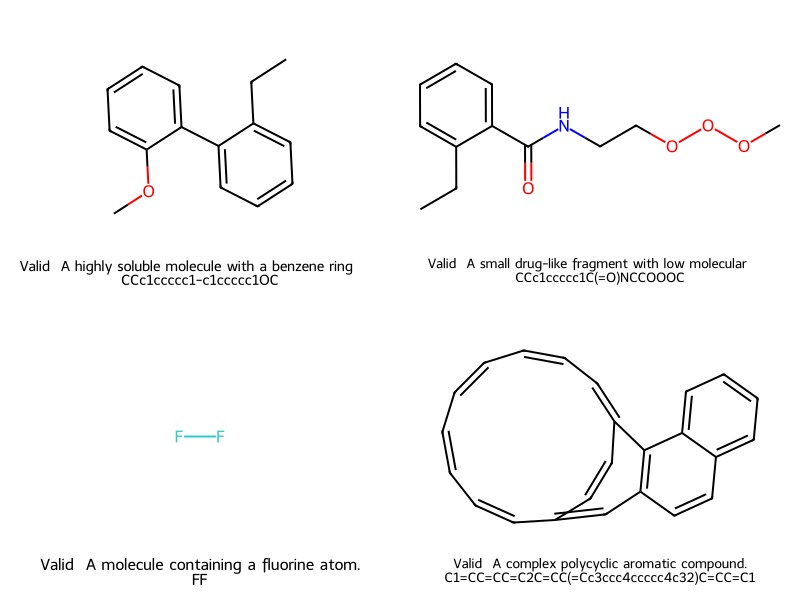

In [ ]:
import torch
import selfies as sf
from pathlib import Path
from rdkit import Chem
from rdkit.Chem import Draw
from IPython.display import display
from transformers import AutoTokenizer

if REPO_PATH not in sys.path:
    sys.path.insert(0, REPO_PATH)

os.chdir(REPO_PATH)

from tokenizer.chemicalTokenizer import ChemicalTokenizer
from model.molecularDiffusionModel import MolecularDiffusionModel
from training.train_text_condition import CONFIG

PROMPTS = [
    "A highly soluble molecule with a benzene ring.",
    "A small drug-like fragment with low molecular weight.",
    "A molecule containing a fluorine atom.",
    "A complex polycyclic aromatic compound.",
]

NUM_CANDIDATES   = 4     # molecules generated per prompt should be equal to PROMPTS length.
CFG_SCALE        = 3.0   # classifier-free guidance strength
NUM_STEPS        = 32    # denoising steps
TEMPERATURE      = 1.0   # sampling temperature

INFERENCE_CHECKPOINT = os.path.join(WORK_DIR, "best_finetuned_model.pt")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Load tokenizers 
tokenizer    = ChemicalTokenizer(os.path.join(REPO_PATH, "chemical_tokenizer.json"))
hf_tokenizer = AutoTokenizer.from_pretrained(CONFIG["text_model"])

# Load model 
model = MolecularDiffusionModel(
    vocab_size      = CONFIG["vocab_size"],
    hidden_size     = CONFIG["hidden_size"],
    num_heads       = CONFIG["num_heads"],
    ffn_dim         = CONFIG["ffn_dim"],
    num_layers      = CONFIG["num_layers"],
    max_length      = CONFIG["max_length"],
    pad_token_id    = tokenizer.pad_token_id,
    text_model_name = CONFIG["text_model"],
    dropout         = 0.0,
).to(device)

assert os.path.exists(INFERENCE_CHECKPOINT), \
    f"Checkpoint not found: {INFERENCE_CHECKPOINT}\nRun the training or save cell first."

ckpt = torch.load(INFERENCE_CHECKPOINT, map_location=device)
model.load_state_dict(ckpt["model"], strict=False)
model.eval()
print(f"Loaded checkpoint from: {INFERENCE_CHECKPOINT}\n")

# Generation loop
max_length = CONFIG["max_length"]

text_inputs      = hf_tokenizer(PROMPTS, padding=True, truncation=True, return_tensors="pt").to(device)
text_padding_mask = (text_inputs["attention_mask"] == 0)

with torch.no_grad():
    text_embeds = model.get_text_embeddings(text_inputs["input_ids"], text_inputs["attention_mask"])
    null_embeds = model.null_token.expand(NUM_CANDIDATES, text_embeds.size(1), -1)

    input_ids = torch.full((NUM_CANDIDATES, max_length), tokenizer.mask_token_id, device=device)
    t_vals    = torch.linspace(1.0, 0.0, NUM_STEPS, device=device)

    for step_idx, t_val in enumerate(t_vals):
        step_t = t_val.repeat(NUM_CANDIDATES).unsqueeze(-1)

        cond_logits   = model(input_ids, step_t, text_embeds,  text_padding_mask)
        uncond_logits = model(input_ids, step_t, null_embeds,  text_padding_mask)
        logits = uncond_logits + CFG_SCALE * (cond_logits - uncond_logits)

        # On the final step allow the mask token to be predicted
        if step_idx < NUM_STEPS - 1:
            logits[:, :, tokenizer.mask_token_id] = float('-inf')

        probs      = torch.softmax(logits / TEMPERATURE, dim=-1)
        sampled    = torch.distributions.Categorical(probs=probs).sample()
        confidence = torch.gather(probs, 2, sampled.unsqueeze(-1)).squeeze(-1)

        alpha_t     = (torch.cos(t_val * torch.pi / 2) ** 2).item()
        num_to_mask = int((1.0 - alpha_t) * max_length)

        if num_to_mask > 0 and step_idx < NUM_STEPS - 1:
            _, mask_idx = torch.topk(confidence, num_to_mask, dim=-1, largest=False)
            sampled.scatter_(1, mask_idx, tokenizer.mask_token_id)

        input_ids = sampled

# Decode & display

for i, prompt in enumerate(PROMPTS):
    ids = input_ids[i].cpu().tolist()
    if tokenizer.eos_token_id in ids:
        ids = ids[:ids.index(tokenizer.eos_token_id)]

    selfies_str = tokenizer.decode(ids)
    mol, smiles, status = None, "", "invalid"

    try:
        smiles = sf.decoder(selfies_str)
        mol    = Chem.MolFromSmiles(smiles)
        if mol:
            smiles = Chem.MolToSmiles(mol)
            status = "Valid"
        else:
            mol = None
    except Exception:
        pass

    mols.append(mol)
    label = f"{status}  {prompt[:45]}{'…' if len(prompt)>45 else ''}\n{smiles or selfies_str[:40]}"
    legends.append(label)

    print(f"[{i}] {status}  Prompt : {prompt}")
    print(f"       SELFIES: {selfies_str}")
    print(f"       SMILES : {smiles or '(decode failed)'}\n")

# Draw valid molecules; substitute a blank for failed ones
valid_mols = [m if m else Chem.MolFromSmiles("C") for m in mols]
img = Draw.MolsToGridImage(
    valid_mols,
    molsPerRow=2,
    subImgSize=(400, 300),
    legends=legends,
)
display(img)

In [ ]:
# Eval

import subprocess
subprocess.run(["pip", "install", "-q", "nltk", "python-Levenshtein"], check=True)

import nltk
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)

import pandas as pd
import numpy as np
import torch
import selfies as sf
from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs, Scaffolds
from rdkit.Chem.Scaffolds import MurckoScaffold
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
import Levenshtein as lev
from tqdm.auto import tqdm

# Config
TEST_CSV         = os.path.join(WORK_DIR, "test.csv")
EVAL_BATCH_SIZE  = 32      # prompts per GPU batch
EVAL_CFG_SCALE   = 3.0
EVAL_NUM_STEPS   = 32
EVAL_TEMPERATURE = 1.0
MAX_ROWS         = None 

assert os.path.exists(TEST_CSV), f"test.csv not found at {TEST_CSV}"
test_df = pd.read_csv(TEST_CSV)
if MAX_ROWS:
    test_df = test_df.head(MAX_ROWS)
print(f"Evaluating on {len(test_df):,} test rows")

# Inference helper
def generate_selfies_batch(prompts: list) -> list:
    """Masked-diffusion inference; returns one SELFIES string per prompt."""
    n = len(prompts)
    text_inputs = hf_tokenizer(
        prompts, padding=True, truncation=True, return_tensors="pt"
    ).to(device)
    text_padding_mask = (text_inputs["attention_mask"] == 0)

    with torch.no_grad():
        text_embeds = model.get_text_embeddings(
            text_inputs["input_ids"], text_inputs["attention_mask"]
        )
        null_embeds = model.null_token.expand(n, text_embeds.size(1), -1)
        input_ids   = torch.full((n, max_length), tokenizer.mask_token_id, device=device)
        t_vals      = torch.linspace(1.0, 0.0, EVAL_NUM_STEPS, device=device)

        for step_idx, t_val in enumerate(t_vals):
            step_t        = t_val.repeat(n).unsqueeze(-1)
            cond_logits   = model(input_ids, step_t, text_embeds,  text_padding_mask)
            uncond_logits = model(input_ids, step_t, null_embeds,  text_padding_mask)
            logits        = uncond_logits + EVAL_CFG_SCALE * (cond_logits - uncond_logits)

            if step_idx < EVAL_NUM_STEPS - 1:
                logits[:, :, tokenizer.mask_token_id] = float("-inf")

            probs      = torch.softmax(logits / EVAL_TEMPERATURE, dim=-1)
            sampled    = torch.distributions.Categorical(probs=probs).sample()
            confidence = torch.gather(probs, 2, sampled.unsqueeze(-1)).squeeze(-1)

            alpha_t     = (torch.cos(t_val * torch.pi / 2) ** 2).item()
            num_to_mask = int((1.0 - alpha_t) * max_length)
            if num_to_mask > 0 and step_idx < EVAL_NUM_STEPS - 1:
                _, mask_idx = torch.topk(confidence, num_to_mask, dim=-1, largest=False)
                sampled.scatter_(1, mask_idx, tokenizer.mask_token_id)
            input_ids = sampled

    out = []
    for i in range(n):
        ids = input_ids[i].cpu().tolist()
        if tokenizer.eos_token_id in ids:
            ids = ids[:ids.index(tokenizer.eos_token_id)]
        out.append(tokenizer.decode(ids))
    return out

# Run inference 
all_prompts   = test_df["prompt"].tolist()
all_targets   = test_df["response"].tolist()
all_generated = []

for start in tqdm(range(0, len(all_prompts), EVAL_BATCH_SIZE), desc="Generating"):
    batch = all_prompts[start : start + EVAL_BATCH_SIZE]
    all_generated.extend(generate_selfies_batch(batch))

# Metric helpers 
smoother = SmoothingFunction().method1

def selfies_to_smiles(selfies_str: str):
    """SELFIES → canonical SMILES, or None if invalid."""
    try:
        smi = sf.decoder(selfies_str)
        mol = Chem.MolFromSmiles(smi)
        return Chem.MolToSmiles(mol) if mol else None
    except Exception:
        return None

def mol_fp(smiles: str):
    """Morgan fingerprint (r=2, 2048 bits), or None."""
    if not smiles:
        return None
    mol = Chem.MolFromSmiles(smiles)
    return AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=2048) if mol else None

def tanimoto(fp1, fp2) -> float:
    if fp1 is None or fp2 is None:
        return 0.0
    return DataStructs.TanimotoSimilarity(fp1, fp2)

def bleu_score(ref_tokens: list, hyp_tokens: list) -> float:
    return sentence_bleu([ref_tokens], hyp_tokens, smoothing_function=smoother)

def token_retention_rate(selfies_str: str) -> float:
    """
    SELFIES → SMILES → SELFIES roundtrip.
    Returns the fraction of original SELFIES tokens present in the
    roundtripped SELFIES (set-based, order-insensitive).
    Measures losslessness of the SELFIES representation.
    """
    try:
        orig_tokens = list(sf.split_selfies(selfies_str))
        if not orig_tokens:
            return 0.0
        smi = sf.decoder(selfies_str)
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            return 0.0
        rt_sf     = sf.encoder(Chem.MolToSmiles(mol))
        rt_tokens = list(sf.split_selfies(rt_sf))
        retained  = sum(1 for t in orig_tokens if t in rt_tokens)
        return retained / len(orig_tokens)
    except Exception:
        return 0.0

def scaffold_match(smi_gen: str, smi_ref: str) -> bool:
    """True if both molecules share the same Murcko scaffold."""
    try:
        s_gen = MurckoScaffold.MurckoScaffoldSmiles(smiles=smi_gen, includeChirality=False)
        s_ref = MurckoScaffold.MurckoScaffoldSmiles(smiles=smi_ref, includeChirality=False)
        return s_gen == s_ref
    except Exception:
        return False

# Compute per-sample metrics 
records = []
for gen_sf, ref_sf in zip(all_generated, all_targets):
    gen_smi = selfies_to_smiles(gen_sf)
    ref_smi = selfies_to_smiles(ref_sf)

    gen_fp = mol_fp(gen_smi)
    ref_fp = mol_fp(ref_smi)

    gen_tokens = list(sf.split_selfies(gen_sf))
    ref_tokens = list(sf.split_selfies(ref_sf))

    records.append({
        "generated_selfies":  gen_sf,
        "reference_selfies":  ref_sf,
        "generated_smiles":   gen_smi or "",
        "reference_smiles":   ref_smi or "",
        # structural validity
        "valid":              gen_smi is not None,
        # exact match (SELFIES string or canonical SMILES)
        "exact_match":        (gen_sf.strip() == ref_sf.strip()) or
                               (gen_smi is not None and gen_smi == ref_smi),
        # token-level similarity (SELFIES tokens as pseudo-words)
        "bleu":               bleu_score(ref_tokens, gen_tokens),
        # string edit distance on raw SELFIES
        "levenshtein":        lev.distance(gen_sf, ref_sf),
        # fingerprint similarity
        "tanimoto":           tanimoto(gen_fp, ref_fp),
        # roundtrip fidelity of generated molecule
        "token_retention":    token_retention_rate(gen_sf),
        # scaffold-level structural match
        "scaffold_match":     scaffold_match(gen_smi, ref_smi) if (gen_smi and ref_smi) else False,
        # normalised edit distance (0 = identical, 1 = completely different)
        "norm_levenshtein":   lev.distance(gen_sf, ref_sf) / max(len(gen_sf), len(ref_sf), 1),
    })

results_df = pd.DataFrame(records)
valid_mask = results_df["valid"]

# Aggregate 
metrics = {
    "Validity (%)": valid_mask.mean() * 100,
    "Exact Match (%)": results_df["exact_match"].mean() * 100,
    "Scaffold Match — valid pairs (%)": results_df.loc[valid_mask, "scaffold_match"].mean() * 100,
    "BLEU Score (avg)": results_df["bleu"].mean(),
    "Levenshtein Distance (avg)": results_df["levenshtein"].mean(),
    "Normalised Levenshtein (avg)": results_df["norm_levenshtein"].mean(),
    "Tanimoto Similarity (avg, all)": results_df["tanimoto"].mean(),
    "Tanimoto Similarity (avg, valid pairs)": results_df.loc[valid_mask, "tanimoto"].mean()
                                                if valid_mask.any() else float("nan"),
    "Token Retention Rate (avg, generated)": results_df["token_retention"].mean(),
}

print()
print("=" * 60)
print("  MODEL EVALUATION  —  test.csv")
print("=" * 60)
for name, val in metrics.items():
    print(f"  {name:<45s}  {val:>8.4f}")
print("-" * 60)
print(f"  Total samples evaluated : {len(results_df):>8,}")
print(f"  Valid molecules         : {valid_mask.sum():>8,} / {len(results_df):,}")
print("=" * 60)

# Save detailed results 
results_csv = os.path.join(WORK_DIR, "eval_results.csv")
results_df.to_csv(results_csv, index=False)
print(f"
Detailed per-sample results saved → {results_csv}")

In [14]:
!pkill jupyter